# 12주차 3차시: 코퍼스 규모 GraphRAG 파이프라인 (청크 추출·커뮤니티 탐지·로컬/글로벌 검색)

| 주제 | 내용 |
|---|---|
| 코퍼스 청킹 | RecursiveCharacterTextSplitter로 800자 청크 분할 |
| 엔티티·관계 추출 | 청크별 LLM 추출(JSON), 전체 코퍼스 배치 처리 |
| 그래프 병합 | 청크 결과를 단일 DiGraph로 통합, source_chunks 출처 추적 |
| 엔티티 정규화·가중치 | 별칭(부분 문자열) 통합, 노드·엣지 가중치 부여 |
| 커뮤니티 탐지 | Leiden 알고리즘으로 주제 단위 커뮤니티 분할 |
| 커뮤니티 요약 | 커뮤니티별 LLM 요약 생성 |
| 인덱스 영속화 | pickle로 그래프·요약·청크 저장/로드 |
| 로컬 검색 | 엔티티 매칭 + multi-hop 이웃 → 컨텍스트 답변 |
| 글로벌 검색 | 전체 커뮤니티 요약 종합 → 거시 질문 답변 |

In [ ]:
# 환경 설정 및 라이브러리 설치
!pip install -q langchain langchain-openai langchain-community python-dotenv matplotlib networkx graspologic

In [1]:
import os, json, re, time
from pathlib import Path
from collections import defaultdict
from dotenv import load_dotenv

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import font_manager
for f in ["NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic"]:
    if any(f in fn.name for fn in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams["axes.unicode_minus"] = False

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter


/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model='gpt-4o-mini')
corpus = Path('./data/council.txt').read_text(encoding='utf-8')

## 코퍼스 청킹

- 코퍼스(`data/council.txt`)를 `RecursiveCharacterTextSplitter`로 800자 단위 청크로 분할함
- `chunk_overlap=100`으로 청크 경계의 문맥 손실을 완화함
- 이후 모든 엔티티/관계 추출은 청크 단위로 수행됨

In [5]:
# corpus

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100, separators = ['\n\n', '\n', '. ', ' ', ''])
chunks = splitter.split_text(corpus)

In [8]:
len(chunks)

4

In [11]:
chunks[0]

'제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.\n\n제목: 타즈렌 연구소\n타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.\n\n제목: 할렌 프로토콜\n할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.'

## 청크별 엔티티·관계 추출

- LLM에 JSON 스키마(`entities`, `relations`)를 지시해 청크에서 엔티티/관계를 추출함
- `strip_fence`로 코드펜스를 제거하고, JSON 파싱 실패 시 빈 결과로 처리함(견고성 확보)
- `extract_all_chunks`로 전체 코퍼스를 배치 추출하며, 각 결과에 `chunk_index`(출처 청크)를 기록함

In [9]:
EXTRACTION_PROMPT = '''You are an information extraction system.
Extract entities and relations from the text as JSON.

Schema:
{
  "entities":  [{"name": "...", "type": "Person|Organisation|Product|Concept"}],
  "relations": [{"source": "...", "target": "...", "label": "..."}]
}
Output ONLY valid JSON. No commentary.'''

In [10]:
def strip_fence(t):
    t = t.strip()
    if t.startswith("```"):
        t = re.sub(r"^```(?:json)?\s*", "", t); t = re.sub(r"\s*```$", "", t)
    return t

In [12]:
def extract_one_chunk(chunk) -> dict:
    msgs = [SystemMessage(content = EXTRACTION_PROMPT),
           HumanMessage(content = f'Text:\n\"\"\"{chunk}\"\"\"')]
    raw = llm.invoke(msgs).content
    try:
        return json.loads(strip_fence(raw))
    except json.JSONDecodeError:
        return {'entities' : [], 'relations' : []}

In [13]:
sample = extract_one_chunk(chunks[0])
# sample

{'entities': [{'name': '모리카이 센', 'type': 'Person'},
  {'name': '콰빅스 연구소', 'type': 'Organisation'},
  {'name': '브렌술 아카데미', 'type': 'Organisation'},
  {'name': '탈라미르 헤쉬', 'type': 'Person'},
  {'name': '벨트란 사고 엔진', 'type': 'Product'},
  {'name': '눌마리 연구 위원회', 'type': 'Organisation'},
  {'name': '타즈렌 연구소', 'type': 'Organisation'},
  {'name': '리네아 오보스트', 'type': 'Person'},
  {'name': '드리파 아키텍처', 'type': 'Product'},
  {'name': '할렌 프로토콜', 'type': 'Product'},
  {'name': '에빈 브로스', 'type': 'Person'}],
 'relations': [{'source': '모리카이 센', 'target': '콰빅스 연구소', 'label': '설립'},
  {'source': '모리카이 센', 'target': '브렌술 아카데미', 'label': '박사후 연구원'},
  {'source': '탈라미르 헤쉬', 'target': '모리카이 센', 'label': '지도 교수'},
  {'source': '콰빅스 연구소', 'target': '벨트란 사고 엔진', 'label': '대표 프로젝트'},
  {'source': '눌마리 연구 위원회', 'target': '콰빅스 연구소', 'label': '후원 기관'},
  {'source': '리네아 오보스트', 'target': '타즈렌 연구소', 'label': '설립'},
  {'source': '리네아 오보스트', 'target': '해양학 박사', 'label': '전환'},
  {'source': '타즈렌 연구소', 'target': '드리파 아키텍처

In [14]:
def extract_all_chunks(chunks) -> list[dict]:
    results = []
    for i, c in enumerate(chunks):
        r = extract_one_chunk(c)
        r['chunk_index'] = i
        results.append(r)
        print(f" chunk {i} : {len(r['entities'])} entities, {len(r['relations'])} relations")
    return results

In [15]:
chunk_results = extract_all_chunks(chunks)

 chunk 0 : 11 entities, 10 relations
 chunk 1 : 8 entities, 6 relations
 chunk 2 : 10 entities, 9 relations
 chunk 3 : 3 entities, 2 relations


In [16]:
total_e = sum(len(r['entities']) for r in chunk_results)
total_r = sum(len(r['relations']) for r in chunk_results)

In [17]:
total_e, total_r

(32, 27)

In [18]:
chunk_results

[{'entities': [{'name': '콰빅스 연구소', 'type': 'Organisation'},
   {'name': '모리카이 센', 'type': 'Person'},
   {'name': '브렌술 아카데미', 'type': 'Organisation'},
   {'name': '탈라미르 헤쉬', 'type': 'Person'},
   {'name': '벨트란 사고 엔진', 'type': 'Product'},
   {'name': '눌마리 연구 위원회', 'type': 'Organisation'},
   {'name': '타즈렌 연구소', 'type': 'Organisation'},
   {'name': '리네아 오보스트', 'type': 'Person'},
   {'name': '드리파 아키텍처', 'type': 'Product'},
   {'name': '할렌 프로토콜', 'type': 'Concept'},
   {'name': '에빈 브로스', 'type': 'Person'}],
  'relations': [{'source': '모리카이 센', 'target': '콰빅스 연구소', 'label': '설립자'},
   {'source': '모리카이 센', 'target': '브렌술 아카데미', 'label': '연구원'},
   {'source': '탈라미르 헤쉬', 'target': '모리카이 센', 'label': '멘토'},
   {'source': '탈라미르 헤쉬', 'target': '콰빅스 연구소', 'label': '지도 교수'},
   {'source': '벨트란 사고 엔진', 'target': '콰빅스 연구소', 'label': '대표 프로젝트'},
   {'source': '타즈렌 연구소', 'target': '리네아 오보스트', 'label': '설립자'},
   {'source': '리네아 오보스트', 'target': '타즈렌 연구소', 'label': '연구원'},
   {'source': '드리파 아키텍처', 'targ

## 추출 결과 병합 → 지식 그래프

- 청크별 추출 결과를 단일 `nx.DiGraph`로 통합함
- 동일 엔티티가 여러 청크에 등장하면 `source_chunks`에 출처를 누적함
- 동일 엣지에는 여러 관계 `label`과 출처를 누적해 중복을 병합함

In [19]:
def merge_chunk_results(results : list[dict]) -> nx.DiGraph:
    G = nx.DiGraph()
    for r in results:
        ci = r['chunk_index']
        
        for e in r['entities']:
            name = e['name']
            if name in G:
                G.nodes[name]['source_chunks'].append(ci)  # G['오브루리 축제']['source_chunks'] = [0, 3]
            else:
                G.add_node(name, type=e.get('type', 'unknown'), source_chunks=[ci])
        
        for rel in r['relations']:
            s, t = rel['source'], rel['target']
            label = rel.get('label', '')
            if s not in G:
                G.add_node(s, type='unknown', source_chunks=[ci])
            if t not in G:
                G.add_node(t, type='unknown', source_chunks=[ci])
            if G.has_edge(s, t):
                if label and label not in G[s][t]['relations']:
                    G[s][t]['relations'].append(label)
                G[s][t]['source_chunks'].append(ci)
            else:
                G.add_edge(s, t, relations=[label] if label else [], source_chunks=[ci])
        
    return G

In [20]:
G = merge_chunk_results(chunk_results)

In [22]:
G.number_of_nodes(), G.number_of_edges()

(26, 26)

In [24]:
G.nodes(data=True)

NodeDataView({'콰빅스 연구소': {'type': 'Organisation', 'source_chunks': [0]}, '모리카이 센': {'type': 'Person', 'source_chunks': [0]}, '브렌술 아카데미': {'type': 'Organisation', 'source_chunks': [0, 1]}, '탈라미르 헤쉬': {'type': 'Person', 'source_chunks': [0, 1, 1]}, '벨트란 사고 엔진': {'type': 'Product', 'source_chunks': [0, 2]}, '눌마리 연구 위원회': {'type': 'Organisation', 'source_chunks': [0, 1, 3]}, '타즈렌 연구소': {'type': 'Organisation', 'source_chunks': [0]}, '리네아 오보스트': {'type': 'Person', 'source_chunks': [0]}, '드리파 아키텍처': {'type': 'Product', 'source_chunks': [0]}, '할렌 프로토콜': {'type': 'Concept', 'source_chunks': [0, 1]}, '에빈 브로스': {'type': 'Person', 'source_chunks': [0]}, '눌마리 섬': {'type': 'Concept', 'source_chunks': [1, 3]}, '콰빅스': {'type': 'Organisation', 'source_chunks': [1]}, '타즈렌': {'type': 'Organisation', 'source_chunks': [1]}, '공명 프레임에 관하여': {'type': 'unknown', 'source_chunks': [1]}, '코바쉬 연구소': {'type': 'Organisation', 'source_chunks': [2]}, '옌라 톨름': {'type': 'Person', 'source_chunks': [2]}, '발레미르 엔진': {'typ

In [25]:
import collections
sorted(G.nodes(data=True), key=lambda x : -len(x[1].get('source_chunks', [])))

[('탈라미르 헤쉬', {'type': 'Person', 'source_chunks': [0, 1, 1]}),
 ('눌마리 연구 위원회', {'type': 'Organisation', 'source_chunks': [0, 1, 3]}),
 ('브렌술 아카데미', {'type': 'Organisation', 'source_chunks': [0, 1]}),
 ('벨트란 사고 엔진', {'type': 'Product', 'source_chunks': [0, 2]}),
 ('할렌 프로토콜', {'type': 'Concept', 'source_chunks': [0, 1]}),
 ('눌마리 섬', {'type': 'Concept', 'source_chunks': [1, 3]}),
 ('콰빅스 연구소', {'type': 'Organisation', 'source_chunks': [0]}),
 ('모리카이 센', {'type': 'Person', 'source_chunks': [0]}),
 ('타즈렌 연구소', {'type': 'Organisation', 'source_chunks': [0]}),
 ('리네아 오보스트', {'type': 'Person', 'source_chunks': [0]}),
 ('드리파 아키텍처', {'type': 'Product', 'source_chunks': [0]}),
 ('에빈 브로스', {'type': 'Person', 'source_chunks': [0]}),
 ('콰빅스', {'type': 'Organisation', 'source_chunks': [1]}),
 ('타즈렌', {'type': 'Organisation', 'source_chunks': [1]}),
 ('공명 프레임에 관하여', {'type': 'unknown', 'source_chunks': [1]}),
 ('코바쉬 연구소', {'type': 'Organisation', 'source_chunks': [2]}),
 ('옌라 톨름', {'type': 'Person', 'so

## 엔티티 정규화 & 엣지 가중치

- 부분 문자열 별칭(예: `센` → `모리카이 센`)을 탐지해 같은 엔티티로 통합함
- 별칭 통합 후 그래프를 재구성하며 자기 루프·중복 엣지를 제거함
- `source_chunks` 개수를 노드·엣지 `weight`로 부여해 중요도를 수치화함

In [26]:
def resolve_entities(G: nx.DiGraph) -> nx.DiGraph:
    nodes = list(G.nodes)
    
    aliases = {}
    for short in nodes: # 센
        for long in nodes: # 모리카이 센
            if short != long and len(short) < len(long) and short in long:
                aliases[short] = long  # aliases['센'] = '모리카이 센'
                break
    
    def resolve(n):
        
        seen = set()
        
        while n in aliases and n not in seen:
            seen.add(n)
            n = aliases[n]
        
        return n
    
    G2 = nx.DiGraph()
    for n in nodes:
        c = resolve(n)
        if c not in G2:
            G2.add_node(c, **G.nodes[n])
    
    for u, v, d in G.edges(data=True):
        cu, cv = resolve(u), resolve(v)
        
        if cu == cv:
            continue
        if G2.has_edge(cu, cv):
            continue
        G2.add_edge(cu, cv, **d)
    
    return G2

In [27]:
G.number_of_nodes()

26

In [28]:
G = resolve_entities(G)
G.number_of_nodes()

23

In [ ]:
# G[s][t]['source_chunks']

In [29]:
next(iter(G.edges(data=True)), None)

('모리카이 센', '콰빅스 연구소', {'relations': ['설립자'], 'source_chunks': [0]})

In [30]:
sample_edge = next(iter(G.edges(data=True)), None)

In [31]:
u, v, d = sample_edge
len(d.get('source_chunks'))

1

In [32]:
def add_edge_weights(G : nx.DiGraph) -> nx.DiGraph:
    for u, v, d in G.edges(data=True):
        d['weight'] = len(d.get('source_chunks', []))
    for n, d in G.nodes(data=True):
        d['weight'] = len(d.get('source_chunks', []))
    
    return G

In [33]:
G = add_edge_weights(G)

In [34]:
G.edges(data=True)

OutEdgeDataView([('모리카이 센', '콰빅스 연구소', {'relations': ['설립자'], 'source_chunks': [0], 'weight': 1}), ('모리카이 센', '브렌술 아카데미', {'relations': ['연구원'], 'source_chunks': [0], 'weight': 1}), ('브렌술 아카데미', '탈라미르 헤쉬', {'relations': ['current_head', 'authored_paper'], 'source_chunks': [1, 1], 'weight': 2}), ('탈라미르 헤쉬', '모리카이 센', {'relations': ['멘토'], 'source_chunks': [0], 'weight': 1}), ('탈라미르 헤쉬', '콰빅스 연구소', {'relations': ['지도 교수'], 'source_chunks': [0], 'weight': 1}), ('탈라미르 헤쉬', '공명 프레임에 관하여', {'relations': ['wrote'], 'source_chunks': [1], 'weight': 1}), ('벨트란 사고 엔진', '콰빅스 연구소', {'relations': ['대표 프로젝트'], 'source_chunks': [0], 'weight': 1}), ('눌마리 연구 위원회', '콰빅스 연구소', {'relations': ['collaborates_with'], 'source_chunks': [1], 'weight': 1}), ('눌마리 연구 위원회', '타즈렌 연구소', {'relations': ['collaborates_with'], 'source_chunks': [1], 'weight': 1}), ('눌마리 연구 위원회', '브렌술 아카데미', {'relations': ['collaborates_with'], 'source_chunks': [1], 'weight': 1}), ('타즈렌 연구소', '리네아 오보스트', {'relations': ['설립자'], 'source_chun

## 지식 그래프 시각화

- 엔티티 `type`별 색상 맵으로 노드를 구분해 그래프를 시각화함
- `spring_layout`으로 노드를 배치하며, 한글 폰트를 적용함

In [37]:
cmap = {"Person": "#FFB347", "Organisation": "#77DD77", "Product": "#AEC6CF",
        "Concept": "#FF6961", "unknown": "#CCCCCC"}

In [38]:
def draw(G, node_color, title="", figsize=(12, 8)):
    pos = nx.spring_layout(G, seed=42, k=1.2)
    plt.figure(figsize= figsize)
    nx.draw(G, pos, node_color= node_color, with_labels=True, node_size=1600, font_size=8, 
            font_family=plt.rcParams.get('font.family', 'sans-serif'),
           arrowsize=10, edge_color="#999", alpha=0.85)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [39]:
colors = [cmap.get(G.nodes[n].get('type', 'unknown'), '#CCC') for n in G.nodes]

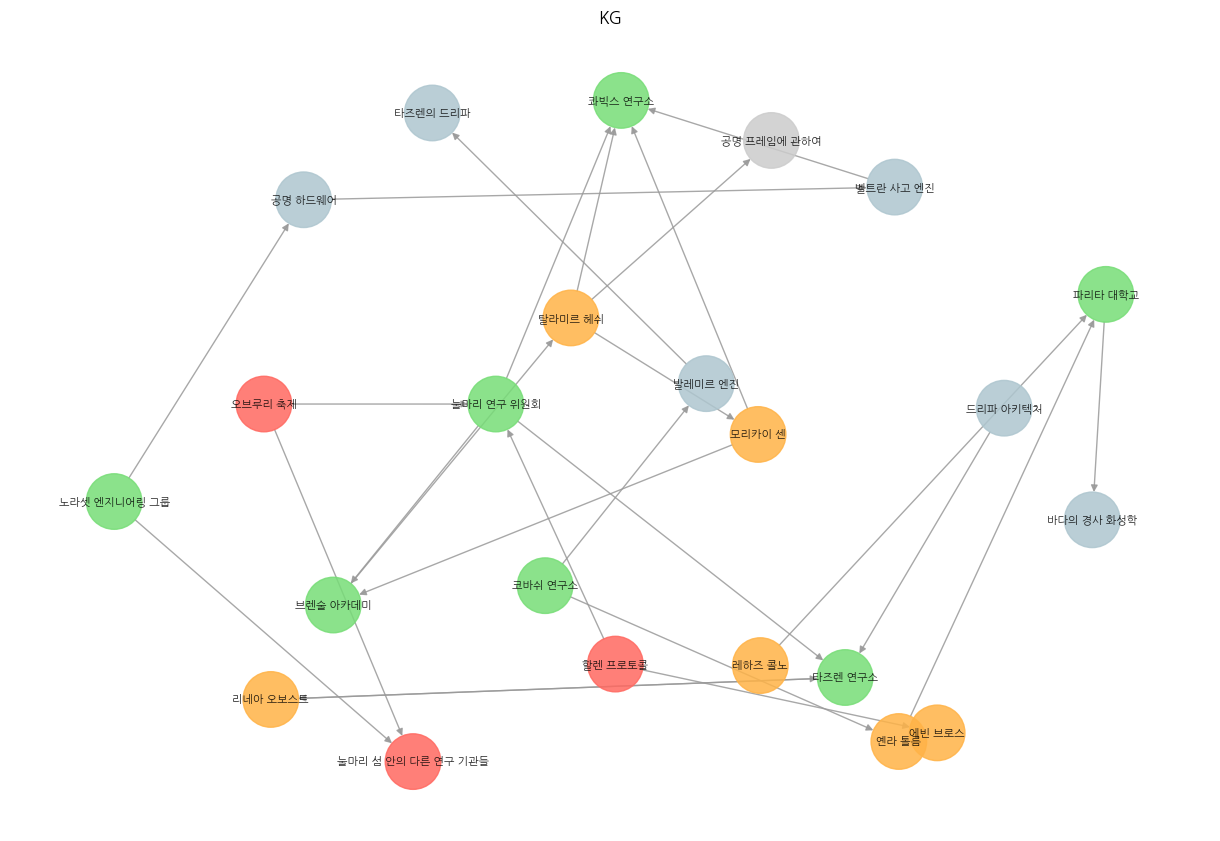

In [41]:
draw(G, colors, 'KG')

## 커뮤니티 탐지 (Leiden)

- 방향 그래프를 무방향으로 변환한 뒤 Leiden 알고리즘으로 커뮤니티를 분할함
- 커뮤니티 = 서로 밀집 연결된 엔티티 그룹으로, 코퍼스의 *주제 단위*에 해당함
- 커뮤니티별 색상으로 다시 시각화해 군집 구조를 확인함

In [42]:
from graspologic.partition import leiden

In [43]:
partitions = leiden(G.to_undirected())

In [45]:
len(set(partitions.values()))

4

In [50]:
# partitions

In [53]:
def detect_comunities(G):
    partitions = leiden(G.to_undirected())
    communities = defaultdict(list)
    for node, cid in partitions.items():
        communities[cid].append(node)
    return dict(communities)

In [54]:
comms = detect_comunities(G)
for cid, nodes in sorted(comms.items()):
    print(f" C{cid} ({len(nodes)} 개) : {nodes}")

 C0 (5 개) : ['모리카이 센', '브렌술 아카데미', '탈라미르 헤쉬', '콰빅스 연구소', '공명 프레임에 관하여']
 C1 (5 개) : ['눌마리 섬 안의 다른 연구 기관들', '노라셋 엔지니어링 그룹', '벨트란 사고 엔진', '오브루리 축제', '공명 하드웨어']
 C2 (6 개) : ['에빈 브로스', '리네아 오보스트', '타즈렌 연구소', '드리파 아키텍처', '눌마리 연구 위원회', '할렌 프로토콜']
 C3 (7 개) : ['타즈렌의 드리파', '발레미르 엔진', '옌라 톨름', '레하즈 콜노', '파리타 대학교', '바다의 경사 화성학', '코바쉬 연구소']


In [56]:
comms

{1: ['눌마리 섬 안의 다른 연구 기관들', '노라셋 엔지니어링 그룹', '벨트란 사고 엔진', '오브루리 축제', '공명 하드웨어'],
 2: ['에빈 브로스', '리네아 오보스트', '타즈렌 연구소', '드리파 아키텍처', '눌마리 연구 위원회', '할렌 프로토콜'],
 3: ['타즈렌의 드리파',
  '발레미르 엔진',
  '옌라 톨름',
  '레하즈 콜노',
  '파리타 대학교',
  '바다의 경사 화성학',
  '코바쉬 연구소'],
 0: ['모리카이 센', '브렌술 아카데미', '탈라미르 헤쉬', '콰빅스 연구소', '공명 프레임에 관하여']}

In [55]:
chunks[0]

'제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.\n\n제목: 타즈렌 연구소\n타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.\n\n제목: 할렌 프로토콜\n할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.'

/tmp/ipykernel_1438446/3167329010.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10', max(comms.keys())+1)


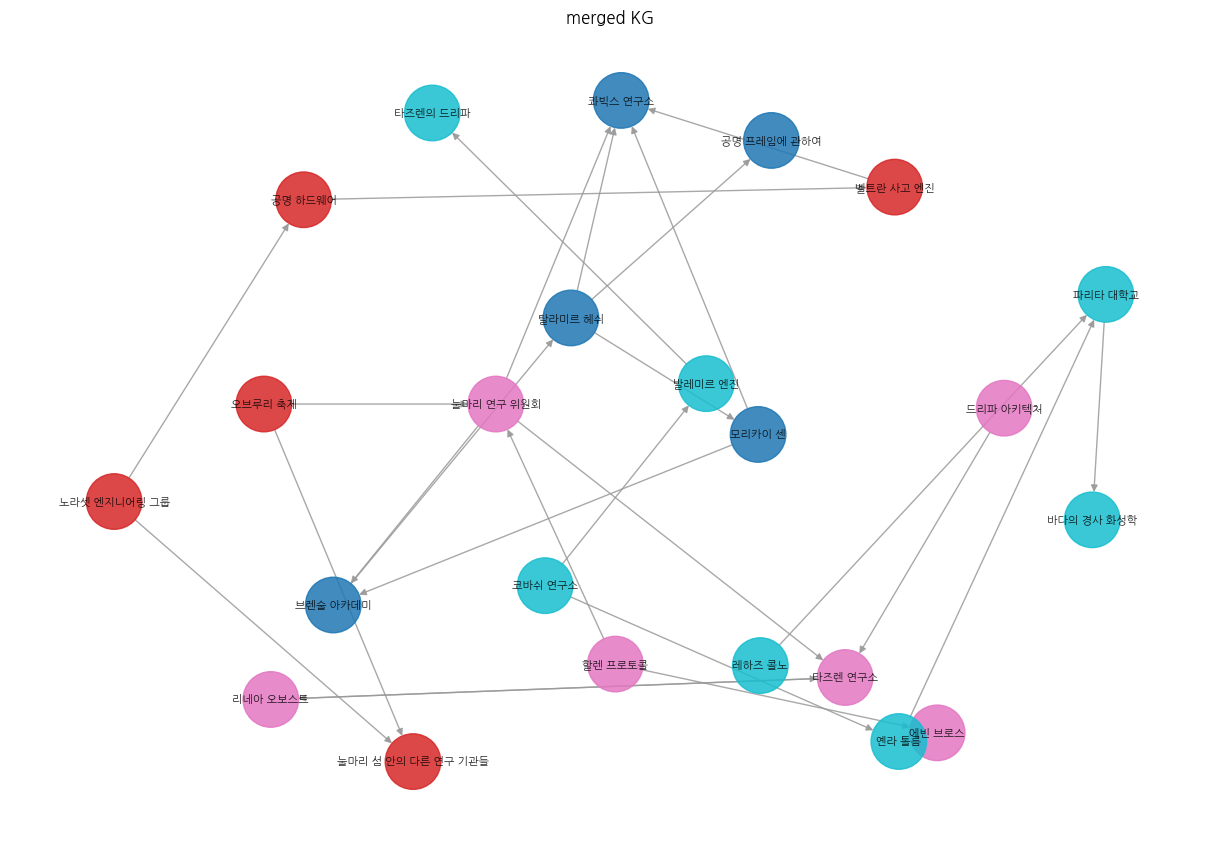

In [57]:
import matplotlib.cm as cm
node_to_cid = {n : cid for cid, nodes in comms.items() for n in nodes}
palette = cm.get_cmap('tab10', max(comms.keys())+1)
comm_colors = [palette(node_to_cid.get(n, 0)) for n in G.nodes]
draw(G, comm_colors, 'merged KG')

In [ ]:
# multi-hop
# relational query

# global query # 전체 corpus 의 주제는 뭔가요? 


## 커뮤니티 요약

- 각 커뮤니티의 엔티티·관계 목록을 LLM에 넘겨 4~6문장 한국어 요약을 생성함
- 이 요약들은 이후 *글로벌 검색*에서 거시적 질문에 답하는 근거가 됨

In [58]:
SUMMARY_PROMPT = """아래는 지식 그래프의 한 커뮤니티에 속한 엔티니와 관계 목록입니다.
이 커뮤니티의 *주제*와 *주요 사실*을 4~6문장의 한국어 단락으로 요약해 주세요.

엔티티 :
{entities}

관계 :
{relations}"""

In [61]:
def summarize_community(G: nx.DiGraph, nodes : list[str]) -> str:
    nodes_set = set(nodes)
    ent_lines = [f"- {n} ({G.nodes[n].get('type', '?')})" for n in nodes]  # [- 눌마리 섬 안의 다른 연구 기관들 (organization)]
    rel_lines = []
    for u, v, d in G.edges(data=True):
        if u in nodes_set and v in nodes_set:
            for rel in (d.get('relations') or [""]):
                rel_lines.append(f"- {u} --[{rel}]--> {v}")
    
    prompt = SUMMARY_PROMPT.format(
        entities = '\n'.join(ent_lines) or "(없음)",
        relations = '\n'.join(rel_lines) or "(없음)"
    )
    
    return llm.invoke([HumanMessage(content = prompt)]).content

In [62]:
summaries = {}
for cid, nodes in comms.items():
    print(f"요약 : C{cid} ({nodes})")
    summaries[cid] = summarize_community(G, nodes)


요약 : C1 (['눌마리 섬 안의 다른 연구 기관들', '노라셋 엔지니어링 그룹', '벨트란 사고 엔진', '오브루리 축제', '공명 하드웨어'])
요약 : C2 (['에빈 브로스', '리네아 오보스트', '타즈렌 연구소', '드리파 아키텍처', '눌마리 연구 위원회', '할렌 프로토콜'])
요약 : C3 (['타즈렌의 드리파', '발레미르 엔진', '옌라 톨름', '레하즈 콜노', '파리타 대학교', '바다의 경사 화성학', '코바쉬 연구소'])
요약 : C0 (['모리카이 센', '브렌술 아카데미', '탈라미르 헤쉬', '콰빅스 연구소', '공명 프레임에 관하여'])


In [63]:
for cid, s in summaries.items():
    print(f"\n[C{cid}] {s[:200]}")


[C1] 이 커뮤니티는 눌마리 섬 안의 연구 기관들과 관련된 다양한 엔티티와 관계를 탐구하고 있습니다. 노라셋 엔지니어링 그룹은 주력 제품인 공명 하드웨어를 통해 기술적 혁신을 이루어내며, 주요 고객은 눌마리 섬의 다른 연구 기관들입니다. 특히, 공명 하드웨어는 벨트란 사고 엔진에 전력을 공급하는 역할을 담당하고 있습니다. 또한 오브루리 축제는 이 지역 연구 기관들

[C2] 이 커뮤니티는 과학 연구와 혁신을 중심으로 한 여러 엔티티로 구성되어 있으며, 주요 인물과 조직들의 협력 관계가 두드러진다. 리네아 오보스트는 타즈렌 연구소의 설립자로, 해당 연구소에서 연구원으로 활동하고 있으며, 드리파 아키텍처에 기여하고 있다. 눌마리 연구 위원회는 타즈렌 연구소와 협력하여 연구를 진행하고 있으며, 이 조직은 에빈 브로스가 작성한 할렌 

[C3] 이 커뮤니티는 주로 교육 및 연구 기관과 관련된 엔티티들로 구성되어 있으며, 특히 인재 양성과 혁신적인 제품 개발에 중점을 두고 있습니다. 코바쉬 연구소는 옌라 톨름을 소장으로 두고 있으며, 이 연구소는 발레미르 엔진의 대표 아키텍처 역할을 맡고 있습니다. 옌라 톨름은 박사 과정을 진행하기 위해 파리타 대학교에 소속되어 있으며, 이 대학은 바다의 경사 화성

[C0] 이 커뮤니티는 모리카이 센과 탈라미르 헤쉬라는 두 주요 인물을 중심으로 구성되어 있습니다. 모리카이 센은 콰빅스 연구소의 설립자이자 브렌술 아카데미의 연구원이며, 탈라미르 헤쉬는 현재 브렌술 아카데미의 소장이자 모리카이 센의 멘토 역할을 하고 있습니다. 또한, 탈라미르 헤쉬는 콰빅스 연구소의 지도 교수로 활동하고 있으며, "공명 프레임에 관하여"라는 논문을


In [64]:
G.number_of_nodes()

23

In [66]:
len(comms), len(summaries)

(4, 4)

In [67]:
len(chunks)

4

## 인덱스 저장 & 로드

- 그래프·커뮤니티·요약·청크를 하나의 `index` 딕셔너리로 묶음
- `pickle`로 직렬화해 저장/로드하며, 재추출 없이 검색 단계를 재현할 수 있음

In [68]:
import pickle
from pathlib import Path

In [69]:
INDEX_PATH = Path("mini_graphrag_index_0611.pkl")

In [71]:
index = {'graph' : G, 'communities' : comms, 'summaries' : summaries, 'chunks' : chunks}

In [70]:
def save_index(index, path=INDEX_PATH):
    with open(path, 'wb') as f:
        pickle.dump(index, f)

def load_index(path = INDEX_PATH) :
    with open(path, 'rb') as f:
        return pickle.load(f)

In [73]:
save_index(index)
restored = load_index()

In [75]:
restored.keys()

dict_keys(['graph', 'communities', 'summaries', 'chunks'])

In [74]:
restored['graph'].number_of_nodes()

23

## 로컬 검색 (Local Search)

- 특정 엔티티에 관한 사실·관계 질문에 답하는 방식임
- 질문에서 엔티티를 찾고, multi-hop 이웃과 그 출처 청크를 모아 컨텍스트로 LLM에 전달함
- 관계 정보를 함께 제공하므로 *multi-hop 추론*이 가능함

In [ ]:
# ㅇㅇ은 누구인가요?
# ㅇㅇ과 ㅁㅁ의 관계는 무엇인가요?

In [ ]:
# 1. ㅇㅇ은 무엇인가요? -> 어떤 entity (ㅇㅇ)를 찾아야 하는지를 mapping 
# 2. entity(ㅇㅇ) 의 neighbors 검색 (1~2, 3 hop)
# 3. entity 의 source_chunks 불러오기
# 4. context -> llm

In [77]:
def local_search(question, index, hops):
    G, chunks = index['graph'], index['chunks']
    matched = [n for n in G.nodes if n in question]
    if not matched:
        return "질문에 해당되는 entity 없음. Global search를 시도해 보세요"
    
    nodes = set(matched) # set(모리카이 센, 센, 모리카이) 
    for _ in range(hops):
        new = set()
        for n in nodes:
            new |= set(G.successors(n)) | set(G.predecessors(n))
        
        nodes |= new
    
    chunk_ids = set()
    for n in nodes:
        chunk_ids |= set(G.nodes[n].get('source_chunks', []))
    
    chunk_text = '\n\n'.join(f"[chunk {i}] {chunks[i]}" for i in sorted(chunk_ids))
    
    edge_lines = []
    for u, v, d in G.edges(data=True):
        if u in nodes and v in nodes:
            for rel in (d.get('relations') or ['']):
                edge_lines.append(f"({u}) --[{rel}]--> ({v})")
    
    edge_text = '\n'.join(edge_lines)
    sys = SystemMessage(content = (
        "주어진 컨텍스트 (원본 텍스트 청크 + 그래프 관계) 만 사용해서 한국어로 답해주세요"
        "관계 정보로 *multi-hop 추론*도 가능합니다. 답이 없으면 '문서에서 찾을수 없음'을 출력하세요"
    ))
    user = HumanMessage(content = f"질문: {question}\n\n관계 : {edge_text}\n\n청크 : {chunk_text}")
    return llm.invoke([sys, user]).content

In [79]:
local_search("모리카이 센의 멘토가 쓴 논문의 제목은 무엇인가요?", index, hops=2)

'모리카이 센의 멘토가 쓴 논문의 제목은 "공명 프레임에 관하여"입니다.'

## 글로벌 검색 (Global Search)

- 코퍼스 전체의 주제·경향처럼 거시적인 질문에 답하는 방식임
- 모든 커뮤니티 요약을 종합해 LLM이 통합 답변을 생성함
- 개별 엔티티가 아니라 *주제 단위 요약*에 기반함

In [ ]:
# 코퍼스의 전체 주제는? 전반적인 트렌드는? 
# 1. 모든 커뮤니티의 요약을 llm에 넘김
# 2. 각 요약을 단서로 '이 질문에 답하는데 도움이 되는 정보 + 점수' 추출
# 3. llm이 종합 답변 생성

In [80]:
all_summary_text = '\n\n'.join(f"[C{cid}]\n{s}" for cid, s in sorted(index['summaries'].items()))

In [82]:
print(all_summary_text)

[C0]
이 커뮤니티는 모리카이 센과 탈라미르 헤쉬라는 두 주요 인물을 중심으로 구성되어 있습니다. 모리카이 센은 콰빅스 연구소의 설립자이자 브렌술 아카데미의 연구원이며, 탈라미르 헤쉬는 현재 브렌술 아카데미의 소장이자 모리카이 센의 멘토 역할을 하고 있습니다. 또한, 탈라미르 헤쉬는 콰빅스 연구소의 지도 교수로 활동하고 있으며, "공명 프레임에 관하여"라는 논문을 저술하기도 했습니다. 이 두 인물 간의 밀접한 관계는 두 기관의 연구 및 학문적 기여도에 중요한 영향을 미치고 있습니다.

[C1]
이 커뮤니티는 눌마리 섬 안의 연구 기관들과 관련된 다양한 엔티티와 관계를 탐구하고 있습니다. 노라셋 엔지니어링 그룹은 주력 제품인 공명 하드웨어를 통해 기술적 혁신을 이루어내며, 주요 고객은 눌마리 섬의 다른 연구 기관들입니다. 특히, 공명 하드웨어는 벨트란 사고 엔진에 전력을 공급하는 역할을 담당하고 있습니다. 또한 오브루리 축제는 이 지역 연구 기관들에서 열리며, 커뮤니티의 지역문화와 혁신을 반영하는 중요한 행사로 자리잡고 있습니다. 이러한 관계들은 눌마리 섬의 기술 발전과 문화적 정체성을 동시에 보여줍니다.

[C2]
이 커뮤니티는 과학 연구와 혁신을 중심으로 한 여러 엔티티로 구성되어 있으며, 주요 인물과 조직들의 협력 관계가 두드러진다. 리네아 오보스트는 타즈렌 연구소의 설립자로, 해당 연구소에서 연구원으로 활동하고 있으며, 드리파 아키텍처에 기여하고 있다. 눌마리 연구 위원회는 타즈렌 연구소와 협력하여 연구를 진행하고 있으며, 이 조직은 에빈 브로스가 작성한 할렌 프로토콜을 채택하였다. 에빈 브로스는 할렌 프로토콜의 작성자로, 이 프로토콜은 누르마리 연구 위원회의 연구 활동에 중요한 역할을 하고 있다. 이러한 관계들은 연구와 혁신을 촉진하는 데 기여하고 있다.

[C3]
이 커뮤니티는 주로 교육 및 연구 기관과 관련된 엔티티들로 구성되어 있으며, 특히 인재 양성과 혁신적인 제품 개발에 중점을 두고 있습니다. 코바쉬 연구소는 옌라 톨름을 소장으로 두고 있으며

In [84]:
# index

In [85]:
def global_search(question, index) -> str:
    all_summary_text = '\n\n'.join(f"[C{cid}]\n{s}" for cid, s in sorted(index['summaries'].items()))
    sys = SystemMessage(content = (
        "당신은 지식 그래프의 *커뮤니티 요약*을 종합해 답하는 전문가입니다"
        "각 요약은 코퍼스의 한 주제 그룹을 다룹니다. 모든 요약을 비교/종합해 한국어로 답하세요"
    ))
    user = HumanMessage(content = f"질문 : {question}\n\n == 커뮤니티 요약 == \n{all_summary_text}")
    return llm.invoke([sys, user]).content

In [86]:
global_search("눌마리 섬의 주요 연구 주제와 기관들의 관계를 요약해주세요", index)

'눌마리 섬의 연구 환경은 여러 주요 인물과 기관 간의 긴밀한 협력 관계를 바탕으로 발전하고 있습니다. 각 커뮤니티의 요약 내용을 통합하면 다음과 같은 주요 사항들을 파악할 수 있습니다.\n\n1. **주요 인물과 기관**:\n   - 모리카이 센과 탈라미르 헤쉬는 콰빅스 연구소와 브렌술 아카데미와 관련된 핵심 인물입니다. 탈라미르 헤쉬는 브렌술 아카데미의 소장이자 모리카이 센의 멘토로, 이들의 협력은 연구에 중요한 기여를 하고 있습니다.\n   - 리네아 오보스트는 타즈렌 연구소의 설립자로, 다양한 연구 프로젝트에 참여하고 있으며, 이는 눌마리 연구 위원회와도 협력하고 있습니다. 에빈 브로스는 할렌 프로토콜의 작성자로, 연구 위원회의 활동에 많은 영향을 미치고 있습니다.\n   - 코바쉬 연구소의 옌라 톨름 소장과 레하즈 콜노 교수는 파리타 대학교와의 관계를 통해 연구와 교육을 발전시키고 있으며, 이들도 발레미르 엔진의 아키텍처와 관련된 혁신에 기여하고 있습니다.\n\n2. **기술 및 혁신**:\n   - 노라셋 엔지니어링 그룹은 눌마리 섬 내 다른 연구 기관들과의 밀접한 연계를 통해 기술적 혁신을 이루고 있으며, 공명 하드웨어는 이는 벨트란 사고 엔진에 전력을 공급하며, 지역의 연구와 개발에 중요한 역할을 하고 있습니다.\n   - 발레미르 엔진과 드리파 아키텍처 간의 경쟁은 기술 발전을 더욱 촉진시키는 요소로 작용하고 있습니다.\n\n3. **문화적 요소**:\n   - 오브루리 축제와 같은 지역 문화 행사는 눌마리 섬의 연구 기관 간의 상호작용을 더욱 강화하며, 연구자와 지역 사회 간의 유대감을 나타냅니다.\n\n이러한 다양한 관계와 활동은 눌마리 섬의 연구 환경을 풍부하게 하고 있으며, 각 기관이 서로의 발전에 기여하는 데 중요한 역할을 하고 있습니다.'